In [8]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from MDN import mdn, Mixture
from cVAE import cVAE
from cVAE_ori import cVAE as cVAE_ori
from tortreinador.models.MDN import mdn as mdn_ori
from tortreinador.utils.View import init_weights
import joblib
import matplotlib.ticker as ticker
from tools import switch_rgb
from sklearn.exceptions import InconsistentVersionWarning
import matplotlib.gridspec as gridspec
import warnings
import math
import pandas as pd
from matplotlib.ticker import ScalarFormatter, MaxNLocator
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Used for ppt charts
plt.rcParams['axes.labelcolor'] = 'black'     # xlabel、ylabel
plt.rcParams['xtick.color']     = 'black'    # x 轴刻度文字
plt.rcParams['ytick.color']     = 'black'  # y 轴刻度文字
plt.rcParams['legend.edgecolor'] = 'white'  # 图例边框颜色
plt.rcParams['legend.facecolor'] = 'white'  # 图例背景色
plt.rcParams['text.color']      = 'black'    # 其他文本
plt.rcParams['axes.grid'] = False
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

plt.rcParams["text.usetex"] = False
# plt.rcParams["text.latex.preamble"] = r"\usepackage{newtxtext,newtxmath}"
# plt.rcParams["ps.fonttype"]  = 42

In [2]:
def chart_preference(ax, sub_dict_length, label_name, label_font_size: int = 16, tick_labelsize: int = 14, 
                     xlocator: float = None, xminorlocator: float = None, ylocator: float = None, yminorlocator: float = None, style: str = 'full'):
    if style not in ['full', 'plain']:
        raise ValueError("Expect 'full' or 'plain' style, but found style as {}".format(style))
    
    ax.axhline(y=0, color='red', linestyle='--', zorder=sub_dict_length)
    
    ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='out', labelsize=tick_labelsize)
    
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')
    
    if style == 'full':
        if xlocator:
            ax.xaxis.set_major_locator(ticker.MultipleLocator(xlocator))
    
        if xminorlocator:
            ax.xaxis.set_minor_locator(ticker.MultipleLocator(xminorlocator))
        
        ax.set_xlabel(label_name, fontsize=label_font_size)
    
        if o == 0 or o == 4:
            ax.set_ylabel("Relative Error(%)", fontsize=label_font_size)
        if o == 0:
            ax.legend(
                # title=title,
                frameon=True,
                framealpha=0.7,
                loc='lower right',
                fontsize=9,
                facecolor='whitesmoke',
                edgecolor='gray',
            )
        # if o == 5 or 0 == 6 or o == 7:
        if ylocator:
            ax.yaxis.set_major_locator(ticker.MultipleLocator(ylocator))
    
        if yminorlocator:
            ax.yaxis.set_minor_locator(ticker.MultipleLocator(yminorlocator))
                
        ax.tick_params(axis='y', which='both', left=True, right=False, direction='out', labelsize=tick_labelsize, pad=2)
        
    else:
        ax.tick_params(axis='y', which='both', left=True, right=False, direction='out', labelsize=tick_labelsize, pad=0.5)
    
    # return ax

def dis_limitation(minimum_dis, maximum_dis):
    
    if minimum_dis < -200:
        tmp_minimum_dis = -200
    
    else:
        tmp_minimum_dis = minimum_dis
    
    if maximum_dis > 200:
        tmp_maximum_dis = 200
    
    else:
        tmp_maximum_dis = maximum_dis
    
    return tmp_minimum_dis, tmp_maximum_dis

def plot_amplitude(tmp_ax, key_length, color_list, slide_collection, window, c, label_text, rasterized: bool = True):
    if key_length == 2:
        color_tmp = [color_list[0], color_list[-3]]
        tmp_ax.fill_between(slide_collection, window[:, 0], window[:, 1],
                            facecolor=(switch_rgb(color_tmp[c])),
                            zorder=key_length - c, edgecolor=switch_rgb(color_tmp[c]), label=label_text,
                            rasterized=rasterized)

    else:
        tmp_ax.fill_between(slide_collection, window[:, 0], window[:, 1],
                            facecolor=(switch_rgb(color_list[c])),
                            zorder=key_length - c, edgecolor=switch_rgb(color_list[c]), label=label_text,
                            rasterized=rasterized)
    
    # return tmp_ax
def scientific_notation(v, fixed_exp=None):
    if v == 0:
        return 0.0
    if math.isnan(v):
        return float('nan'), 0
    if math.isinf(v):
        return float('inf') if v > 0 else float('-inf'), 0
    
    sign = -1 if v < 0 else 1
    x = abs(v)
    e = math.floor(math.log10(x)) if fixed_exp is None else fixed_exp
    m = x / (10 ** e)
    m = sign * m
    # print(f"{x} -> {round(m, 3)} x 10^{e}")        

    # return '${} x 10^{}$'.format(m, e)
    return '{}'.format(m)
    

In [3]:
input_parameters = [
    'Mass',
    'Radius',
    'FeMg',
    'SiMg',
]

output_parameters = [
    'WRF',
    'MRF',
    'CRF',
    'WMF',
    'CMF',
    'CPS',
    'CTP',
    'k2'
]

x_labels = [
    'WRF',
    'MRF',
    'CRF',
    'WMF',
    'CMF',
    '$P_{\mathrm{CMB}}$(TPa)',
    '$T_{\mathrm{CMB}}(10^{3}$K$)$',
    '$k_{2}$'
]
xlocators = [0.05, 0.2, 0.2, 0.02, 0.2, 0.4, 1, 0.2]

ylocators_set_1 = [100, 20, 50, 100, 50, 50, 10, 20]
ylocators_set_2 = [100, 20, 50, 100, 50, 50, 10, 20]
ylocators_set_3 = [100, 20, 50, 100, 50, 50, 10, 20]

yminorlocators_set_1 = [20, 4, 10, 20, 10, 10, 2, 4]
yminorlocators_set_2 = [20, 4, 10, 20, 10, 10, 2, 4]
yminorlocators_set_3 = [20, 4, 10, 20, 10, 10, 2, 4]

xminorlocators = [0.01, 0.04, 0.04, 0.004, 0.04, 0.08, 0.2, 0.04]

# y_max = [200, 75, 150, 200, 200, ]
# y_min = []

img_save_path = ".\\imgs"

colors = ['#2E2252', '#4B3C6A', '#71628E', '#988FB8', '#C5BCDB']
colors_2 = ['#003744', '#005C6D', '#007F8F', '#00A1B2', '#4DD4DE']  # for paper
colors_3 = ['#0D1B2A', '#1B263B', '#415A77', '#778DA9', '#E0E1DD']
colors_for_ppt = ['#91662b', '#a38f66', '#c9ae76']


def title_process(t, mode='scaler'):
    
    if mode == 'scaler':
        return t.split('_')[0] if t.split('_')[0] != '50' else t.split('_')[0] + '_' + t.split('_')[1]
    
    elif mode == 'test_data':
        return t.split('_')[2].split('.')[0] if t.split('_')[2].split('.')[0] != '50' else t.split('_')[-2] + '_' + t.split('_')[-1].split('.')[0]

In [4]:
base_file_path = ".\\data"
cvae_base_file_path = os.path.join(base_file_path, "cVAE")
MDN_base_file_path = os.path.join(base_file_path, "MDN")

In [9]:
sample_size = 75000
# selected_idx = np.random.choice(range(705600), size=sample_size)
selected_idx = np.arange(sample_size)

# model_list = np.array(["5th_best_model.pth", "50th_best_model.pth", "95th_best_model.pth", "ori_best_model.pth"])
model_list = np.array(["5th", "50th", "95th", "ori"])
model_name = "best_model.pth"
cvae_model = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024,
                  c_dim=len(input_parameters), o_dim=len(output_parameters))

cvae_ori = cVAE_ori(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024,
                  c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_model)
cvae_model.eval()

mix = Mixture()
scaler_dicts = {}
model_result_dicts = {}
# processing
for l in model_list:

    cvae_file_path = os.path.join(cvae_base_file_path, l)
    mdn_file_path = os.path.join(MDN_base_file_path, l)

    if os.path.exists(cvae_file_path):
        # scaler_dicts['cvae_' + l] = [joblib.load(os.path.join(cvae_file_path if l != 'ori' else mdn_file_path, "scaler_x.save")), joblib.load(os.path.join(cvae_file_path if l != 'ori' else mdn_file_path, "scaler_y.save"))]
        # if l == 'ori':
        #     scaler_dicts['cvae_' + l] = [joblib.load(os.path.join(base_file_path, l, "scaler_x.save")),
        #                              joblib.load(os.path.join(base_file_path, l, "scaler_y.save"))]

        scaler_dicts['cvae_' + l] = [joblib.load(os.path.join(base_file_path, l, "scaler_x.save")),
                                     joblib.load(os.path.join(base_file_path, l, "scaler_y.save"))]

        if os.path.exists(mdn_file_path):
            scaler_dicts['mdn_' + l] = [joblib.load(os.path.join(base_file_path, l, "scaler_x.save")),
                                        joblib.load(os.path.join(base_file_path, l, "scaler_y.save"))]

    tmp_text_x = np.load(os.path.join(base_file_path, l, "test_x.npy"))[:sample_size, :]
    tmp_text_y = np.load(os.path.join(base_file_path, l, "test_y.npy"))[:sample_size, :]

    # mask = np.vectorize(lambda s: title_t_x in s)(model_list)

    if l != 'ori':
        cvae_model.load_state_dict(torch.load(os.path.join(cvae_file_path, model_name), weights_only=True))

    else:
        cvae_ori.load_state_dict(torch.load(os.path.join(cvae_file_path, model_name), weights_only=True))

    cvae_model.to('cuda')
    fake_y = torch.from_numpy(np.random.normal(0, 1, (len(tmp_text_y), tmp_text_y.shape[-1]))).to(torch.float)
    cvae_pred = cvae_model(fake_y.to('cuda'), torch.from_numpy(tmp_text_x).to('cuda').to(torch.float))
    cvae_pred = cvae_pred[0].cpu().detach().numpy()

    cvae_pred_inverse = scaler_dicts['cvae_' + l][-1].inverse_transform(cvae_pred)
    tmp_test_y_inverse = scaler_dicts['cvae_' + l][-1].inverse_transform(tmp_text_y)

    cvae_pred_inverse[:, 5] = cvae_pred_inverse[:, 5] / 1000
    cvae_pred_inverse[:, 6] = cvae_pred_inverse[:, 6] / 1000

    tmp_test_y_inverse[:, 5] = tmp_test_y_inverse[:, 5] / 1000
    tmp_test_y_inverse[:, 6] = tmp_test_y_inverse[:, 6] / 1000

    model_result_dicts['cvae_' + l] = {}
    model_result_dicts['cvae_' + l]['model_pred'] = cvae_pred
    model_result_dicts['cvae_' + l]['text_y'] = tmp_text_y
    model_result_dicts['cvae_' + l]['model_pred_inverse'] = cvae_pred_inverse
    model_result_dicts['cvae_' + l]['text_y_inverse'] = tmp_test_y_inverse

    # try:
    tmp_mdn_text_x = np.load(os.path.join(base_file_path, l, "test_x.npy"))[:sample_size, :]
    tmp_mdn_text_y = np.load(os.path.join(base_file_path, l, "test_y.npy"))[:sample_size, :]

    # mask = np.vectorize(lambda s: title_t_x in s)(model_list)
    # model_name = model_list[mask][0]

    if l in ['5th', '95th']:
        continue

    if l == 'ori':
        mdn_model_ori = mdn_ori(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512,
                                num_gaussian=10)
        init_weights(mdn_model_ori)
        mdn_model_ori.eval()
        mdn_model_ori.load_state_dict(torch.load(os.path.join(mdn_file_path, model_name)))
        mdn_model_ori.to('cuda')
        mdn_pred = mdn_model_ori(torch.from_numpy(tmp_mdn_text_x).to(torch.double).to('cuda'))

    else:
        mdn_model_new = mdn(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512,
                            num_gaussian=10)
        init_weights(mdn_model_new)
        mdn_model_new.eval()
        mdn_model_new.load_state_dict(torch.load(os.path.join(mdn_file_path, model_name)))
        mdn_model_new.to('cuda')
        mdn_pred = mdn_model_new(torch.from_numpy(tmp_mdn_text_x).to(torch.float).to('cuda'))

    sample = mix(mdn_pred[0], mdn_pred[1], mdn_pred[2]).sample()
    sample = sample.cpu().detach().numpy()
    mdn_pred_inverse = scaler_dicts['mdn_' + l][-1].inverse_transform(sample)
    tmp_mdn_text_y_inverse = scaler_dicts['mdn_' + l][-1].inverse_transform(tmp_mdn_text_y)

    mdn_pred_inverse[:, 5] = mdn_pred_inverse[:, 5] / 1000
    mdn_pred_inverse[:, 6] = mdn_pred_inverse[:, 6] / 1000

    tmp_mdn_text_y_inverse[:, 5] = tmp_mdn_text_y_inverse[:, 5] / 1000
    tmp_mdn_text_y_inverse[:, 6] = tmp_mdn_text_y_inverse[:, 6] / 1000

    model_result_dicts['mdn_' + l] = {}
    model_result_dicts['mdn_' + l]['model_pred'] = sample
    model_result_dicts['mdn_' + l]['text_y'] = tmp_mdn_text_y
    model_result_dicts['mdn_' + l]['model_pred_inverse'] = mdn_pred_inverse
    model_result_dicts['mdn_' + l]['text_y_inverse'] = tmp_mdn_text_y_inverse

RuntimeError: Error(s) in loading state_dict for cVAE:
	size mismatch for decoder.fc_z3.weight: copying a param with shape torch.Size([1024, 2048]) from checkpoint, the shape in current model is torch.Size([2048, 2048]).
	size mismatch for decoder.fc_z3.bias: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([2048]).

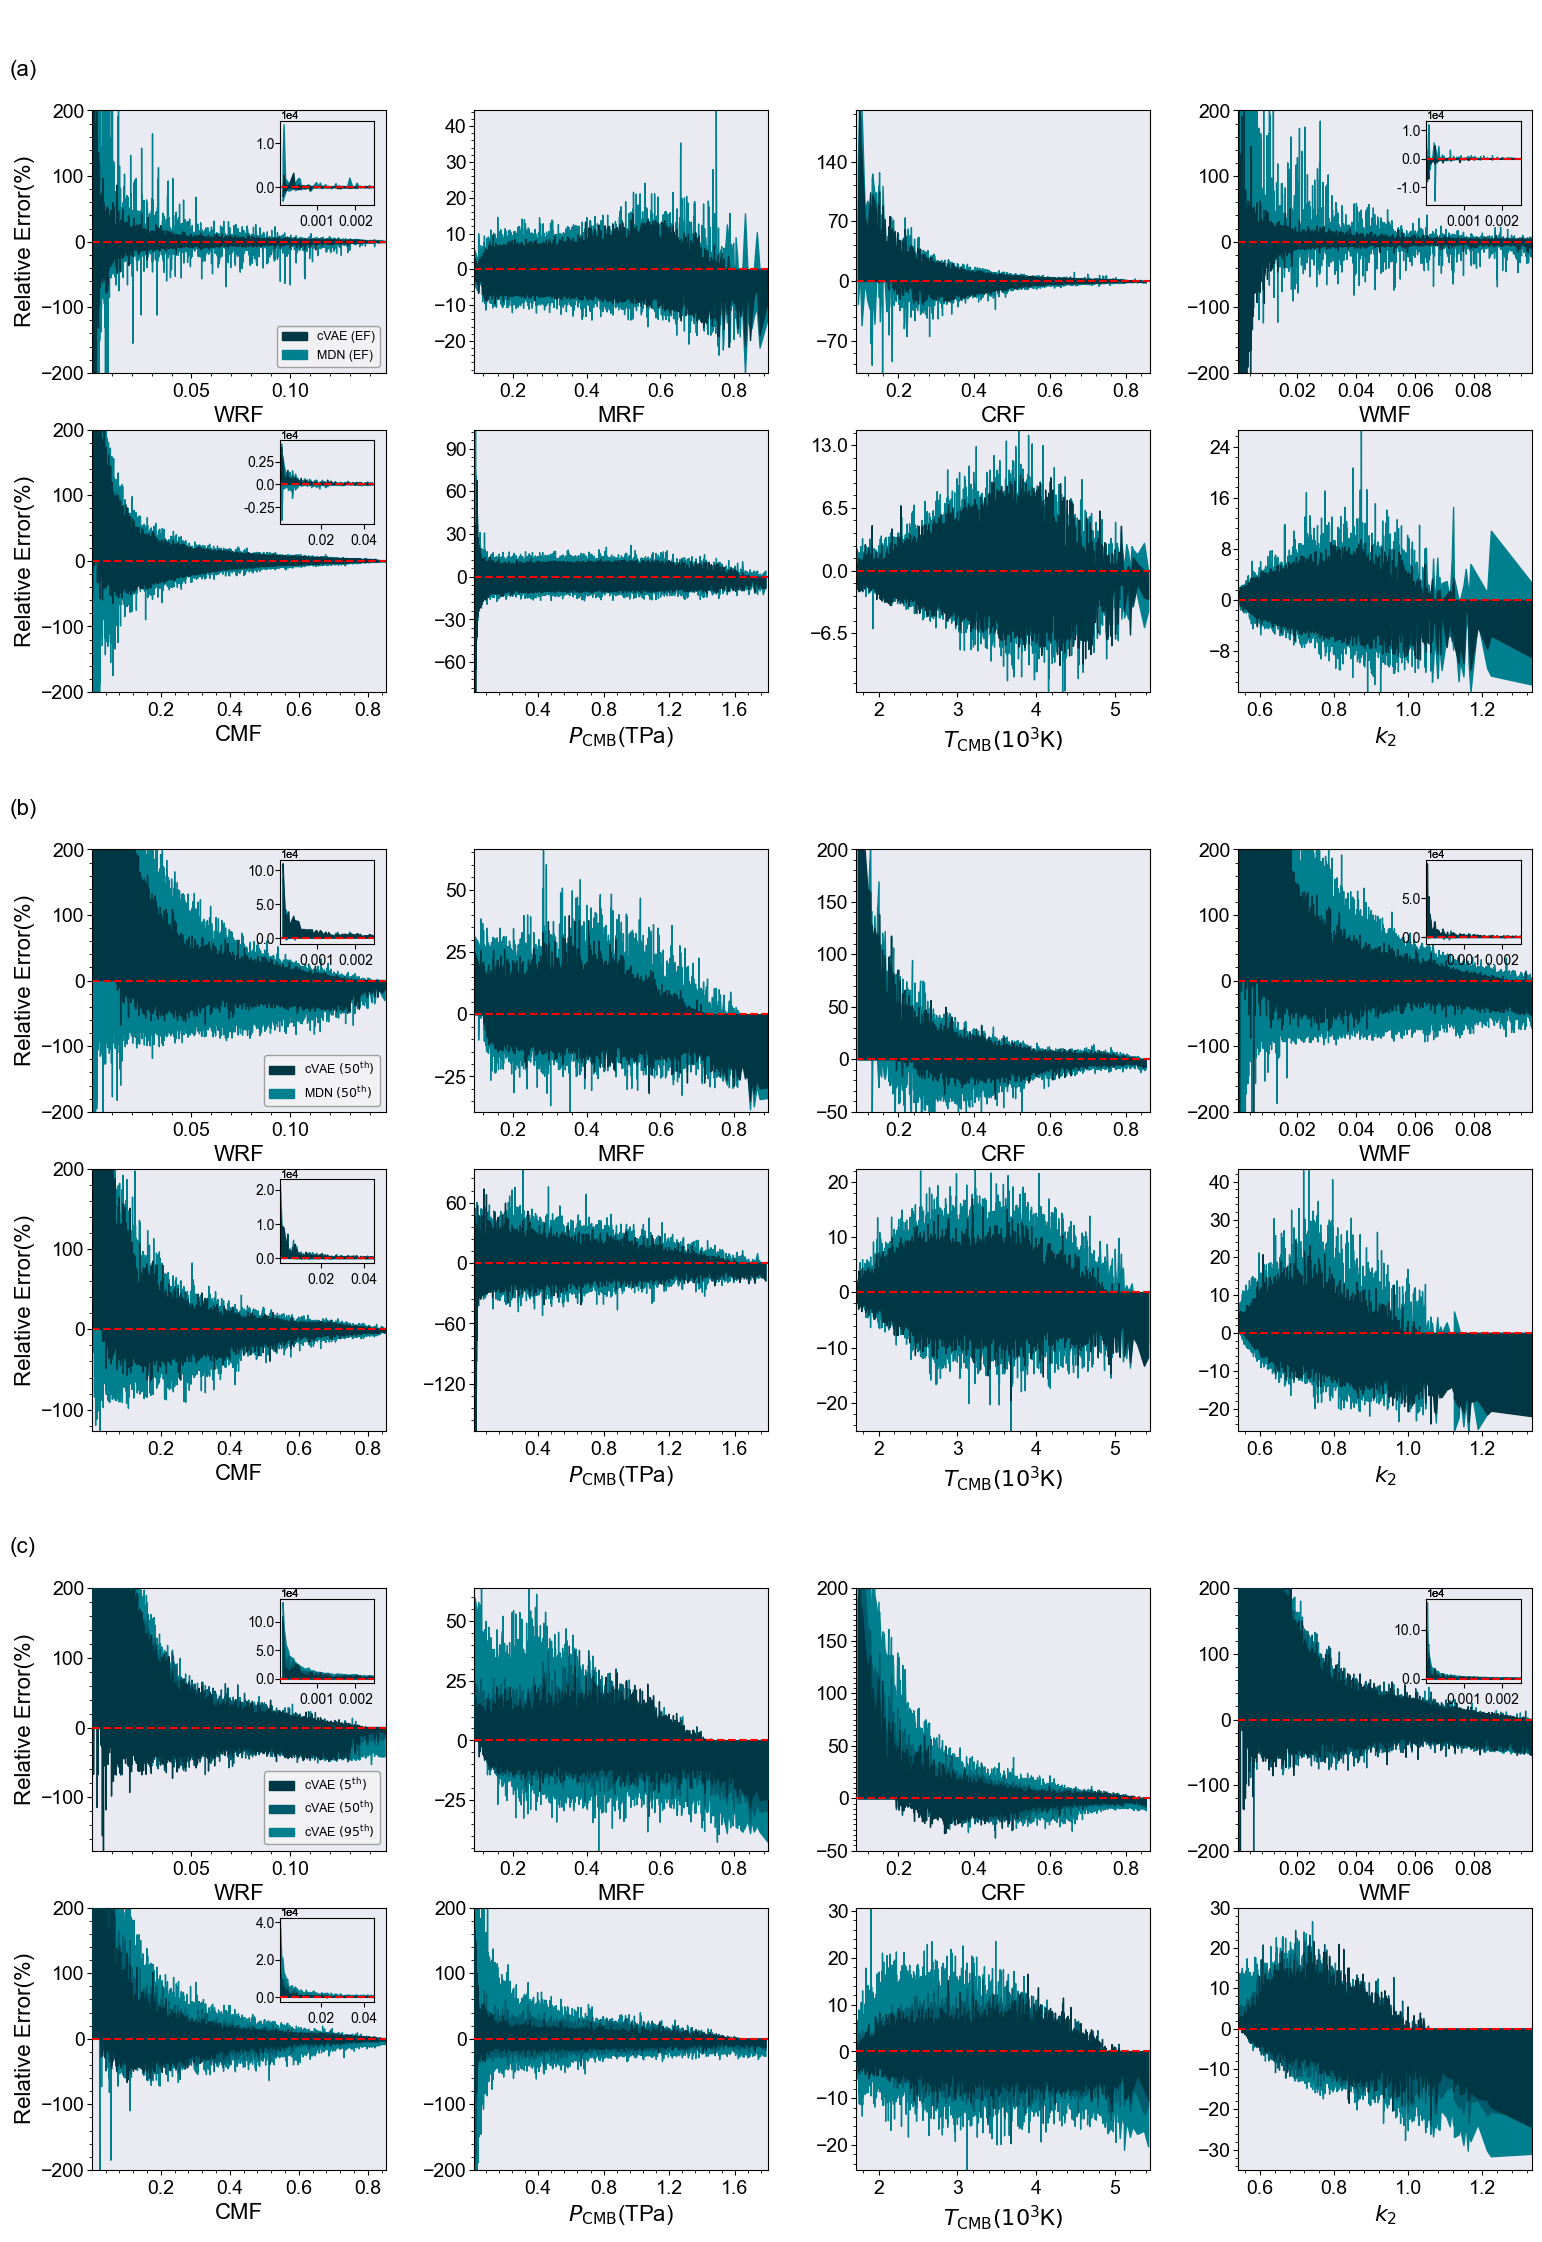

In [6]:
def idx_generator(row_begin, row_end, col):
    tmp = []
    for i in range(row_begin, row_end):
        for j in range(col):
            tmp.append([i, j])
            
    return  tmp

idxs = []
for l in [0, 3, 6]:
    idxs.append(idx_generator(l, l + 3, 4))


slide = 10
stride = slide
condition = 0
obs_error_trend_set = ["cvae_5th", "cvae_50th", "cvae_95th"]
ori_comparison_set = ["cvae_ori", "mdn_ori"]
obs_comparison_set = ["cvae_50th", "mdn_50th"]
set_name = ['ori_comparison', 'obs_comparison', 'obs_error']
serial = ['(a)', '(b)', '(c)']
alpha_set = [1.0, 0.8, 0.6, 0.4, 0.2]

row, col = 3, 4
fig = plt.figure(figsize=(16, 24))
gs = gridspec.GridSpec(row * 3, col, figure=fig, height_ratios=[0.5, 3, 3, 0.5, 3, 3, 0.5, 3, 3])


axs = []
for i in range(len(idxs)):
    tmp = []
    for o in range(len(output_parameters) + 4):
        idx = idxs[i][o]
        ax = fig.add_subplot(gs[idx[0], idx[1]])
        tmp.append(ax)
    
    axs.append(tmp)

axs_inset = []
for i in axs:
    tmp_inset = []
    for j in [0, 3, 4]:
        ax_inset = i[4:][j].inset_axes([0.64, 0.64, 0.32, 0.32])
        tmp_inset.append(ax_inset)
    
    axs_inset.append(tmp_inset)
        
count = 0
for ax in axs:
    sub_axs = ax[:4]
    for i, s_ax in enumerate(sub_axs):
        if i == 0:
            s_ax.text(-0.28, -0.5, serial[count], fontsize=16)
            s_ax.axis('off')
        
        else:
            s_ax.text(1, 1, '')
            s_ax.axis('off')
        
    count += 1


test_v = None
for index, (n, s) in enumerate(zip(set_name, [ori_comparison_set, obs_comparison_set, obs_error_trend_set])):
    
    sub_dict = {k: model_result_dicts[k] for k in s}
    # fig, axs = plt.subplots(2, 4, figsize=(16, 6))
    # axs = axs.flatten()
    max_dis = [0] * len(output_parameters)
    min_dis = [0] * len(output_parameters)
    max_value = [0] * len(output_parameters)
    
    count = -1
    for k, v in sub_dict.items():
        count += 1
        
        for o in range(len(output_parameters)):
            
            sort_idx = np.argsort(v['text_y_inverse'][:, o])
            pred = v['model_pred_inverse'][:, o][sort_idx]
            true = v['text_y_inverse'][:, o][sort_idx]
            dis = (pred - true) / true * 100    # sorted_pred - sorted_true
            
            # percentile_90 = np.percentile(dis, (5, 100))
            # cond_90 = np.where((dis > percentile_90[0]) & (dis < percentile_90[1]))
            # 
            # pred = pred[cond_90]
            # true = true[cond_90]
            # dis = dis[cond_90]
            
            # slide_mean = np.zeros(int(len(true) / stride))
            
            if max(true) > max_value[o]:
                max_value[o] = max(true)
            
            windows = []
            slide_mean = []
            
            for i in range(0, len(true), stride):
                current_window = dis[i:i + slide]
                tmp = []
                positive_value = current_window[np.where(current_window > 0)]
                negative_value = current_window[np.where(current_window < 0)]
                
                if positive_value.size > 0:
                    # positive_median = np.mean(positive_value)
                    positive_median = np.median(positive_value)
                    tmp.append(positive_median)
                
                if negative_value.size > 0:
                    # negative_median = np.mean(negative_value)
                    negative_median = np.median(negative_value)
                    tmp.append(negative_median)
                
                if len(tmp) < 2:
                    tmp = [0 if tmp[0] < 0 else tmp[0], 0 if tmp[0] > 0 else tmp[0]]
                
                else:
                    if i != 0:
                        if tmp[0] > max_dis[o]:
                            max_dis[o] = tmp[0]
                        
                        if tmp[1] < min_dis[o]:
                            min_dis[o] = tmp[1] 
                    
                windows.append(tmp)
                # slide_mean.append(true[i:i + slide].mean())
                slide_mean.append(np.median(true[i:i + slide]))
                
            windows = np.array(windows)
            xs = np.arange(0, len(true), stride)
            # cond = np.sum(windows, axis=1) != 0
            # windows = windows[np.where(cond)]
            # xs = xs[np.where(cond)]
            
            # for i in range(len(xs) - 1):
            #     
            #     # if i < len(xs) - 2:
            #         slide_mean[i] = true[xs[i]:xs[i + 1]].mean()
            #     
            #     # else:
            #     #     slide_mean[i] = true[xs[i]: ].mean()
            
            if condition == 2:
                if o == 0 and k == 'mdn_50th':
                    print(windows)
                    print("Max of this window: {}, Min of this Window: {}".format(max(windows[:, 0]), min(windows[:, 1])))
                    test_v = windows
                    test_d = dis
            
            tmp_label = k.split('_')
            
            # if condition == 0:
            #     label_for_chart = ' ${}$'.format(tmp_label[1].replace('th', '^{th}')) + " " + "R2: {}".format(round(r2_list[o], 2))
            # 
            # elif condition == 1:
            #     label_for_chart = 'Ori' + " " + "R2: {}".format(round(r2_list[o], 2))
            # 
            # elif condition == 2:
            #     if tmp_label[0] == 'cvae':
            #         tmp_label[0] = 'cVAE'
            #     
            #     else:
            #         tmp_label[0] = 'MDN'
            #         
            #     label_for_chart = tmp_label[0] + " " + "R2: {}".format(round(r2_list[o], 2))
            if tmp_label[0] == 'cvae':
                    tmp_label[0] = 'cVAE'
            
            elif tmp_label[0] == 'mdn':
                    tmp_label[0] = 'MDN'
                
            if condition == 1:    
                label_for_chart = tmp_label[0] + ' $({})$'.format(tmp_label[1].replace('th', '^{\mathrm{th}}'))
            
            elif condition == 0:

                label_for_chart = tmp_label[0] + ' (EF)'
            
            elif condition == 2:
                    
                label_for_chart = tmp_label[0] + ' $({})$'.format(tmp_label[1].replace('th', '^{\mathrm{th}}'))
           
            # if o == 0 or o == 3 or o == 4:
            #     slide_mean = slide_mean[1:]
            #     windows = windows[1:, :]
            ax = axs[index][4:][o]
            # ax.fill_between(slide_mean, windows[:, 0], windows[:, 1], 
            #                     facecolor=(switch_rgb(colors_2[count], alpha=alpha_set[count])), 
            #                     zorder=len(sub_dict) - count, edgecolor=switch_rgb(colors_2[count], alpha=0.5), label=label_for_chart)
            # if len(sub_dict.keys()) == 2:
            #     color_tmp = [colors_2[0], colors_2[-3]]
            #     ax.fill_between(slide_mean, windows[:, 0], windows[:, 1], 
            #                         facecolor=(switch_rgb(color_tmp[count])), 
            #                         zorder=len(sub_dict) - count, edgecolor=switch_rgb(color_tmp[count]), label=label_for_chart, rasterized=True)
            #     
            # else:
            #     ax.fill_between(slide_mean, windows[:, 0], windows[:, 1], 
            #                         facecolor=(switch_rgb(colors_2[count])), 
            #                         zorder=len(sub_dict) - count, edgecolor=switch_rgb(colors_2[count]), label=label_for_chart, rasterized=True)
            
            plot_amplitude(ax, len(sub_dict.keys()), colors_2, slide_mean, windows, count, label_for_chart)
            
            # axs[o].set_ylim(min_dis[o], max_dis[o])
            # if o == 2 or o == 4:
            #     print("Model: {}, Feature: {}, Max Dis: {}".format(k, output_parameters[o], max_dis[o]))
            
            
            if n == 'obs_comparison' and o == 2:
                tmp_min_dis, tmp_max_dis = -50, 200
            
            elif n == 'obs_error' and o == 2:
                tmp_min_dis, tmp_max_dis = -50, 200
            
            elif n == 'obs_error' and o == 7:
                tmp_min_dis, tmp_max_dis = -35, 30
            else:
                tmp_min_dis, tmp_max_dis = dis_limitation(min_dis[o], max_dis[o])
 

            ax.set_ylim(tmp_min_dis, tmp_max_dis)
            ax.set_xlim(min(true), max(true))
            
            """
                Inset Plot
            """
            if o == 0 or o == 3 or o == 4:
                inset_idx = o if o == 0 else o - 2
                # windows[:, 0] = scientific_notation(windows[:, 0])
                ax_inset = axs_inset[index][inset_idx]
                plot_amplitude(ax_inset, len(sub_dict.keys()), colors_2, slide_mean, windows, count, label_for_chart)
                
                amp_yticks = ax_inset.get_yticks()
                alternative_set = []
                for y_t in amp_yticks:
                    alternative_set.append(scientific_notation(y_t, 4))
                
                
                ax_inset.set_yticklabels(alternative_set)
                if o == 0 or o == 3:
                    ax_inset.set_xlim(min(true), 0.0025)
                
                elif o == 4:
                    ax_inset.set_xlim(min(true), 0.045)

                ax_inset.text(0, 1.02, '1e4', transform=ax_inset.transAxes, fontsize=8)
    current_ylocators = None
    current_yminilocator = None
    if n == 'ori_comparison':
        current_ylocators = ylocators_set_1
        current_yminilocator = yminorlocators_set_1
    
    elif n == 'obs_comparison':
        current_ylocators = ylocators_set_2
        current_yminilocator = yminorlocators_set_2
    
    elif n == 'obs_error':
        current_ylocators = ylocators_set_3
        current_yminilocator = yminorlocators_set_3

    for o in range(len(output_parameters)):
        # ax = axs[index][4:][o]
        # y_min, y_max = axs[index][4:][o].get_ylim()
        # y_min_max_interval = int(y_max + np.abs(y_min)) / 4

        chart_preference(axs[index][4:][o], len(sub_dict), label_name=x_labels[o], label_font_size=16,
                              tick_labelsize=14, xlocator=xlocators[o], xminorlocator=xminorlocators[o], ylocator=current_ylocators[o], yminorlocator=current_yminilocator[o])
        
        if o == 0 or o == 3 or o == 4:
            inset_idx = o if o == 0 else o - 2
            chart_preference(axs_inset[index][inset_idx], len(sub_dict), label_name=x_labels[o],
                              tick_labelsize=10, xlocator=xlocators[o], xminorlocator=xminorlocators[o], style='plain')
        
        
    condition += 1

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.3, hspace=0.3)
plt.grid(False)
# fig.savefig(os.path.join(img_save_path, 'amplitude_inset_{}.pdf'.format(slide)), dpi=300, bbox_inches='tight', transparent=True)


In [13]:
for index, (n, s) in enumerate(zip(set_name, [ori_comparison_set, obs_comparison_set, obs_error_trend_set])):
    
    sub_dict = {k: model_result_dicts[k] for k in s}
    # fig, axs = plt.subplots(2, 4, figsize=(16, 6))
    # axs = axs.flatten()
    max_dis = [0] * len(output_parameters)
    min_dis = [0] * len(output_parameters)
    max_value = [0] * len(output_parameters)
    
    count = -1
    for k, v in sub_dict.items():
        count += 1
        # r2_list = get_columns_r2(v['text_y'], v['model_pred_inverse'])
        
        for o in range(len(output_parameters)):
            
            sort_idx = np.argsort(v['text_y'][:, o])
            pred = v['model_pred'][:, o][sort_idx]
            true = v['text_y'][:, o][sort_idx]
            dis = (pred - true) / true * 100    # sorted_pred - sorted_true
            
            print("Model: {}, Feature: {}, Maximum dis: {}, Minimum dis: {}".format(k, output_parameters[o], max(dis), min(dis)))
    


Model: cvae_ori, Feature: WRF, Maximum dis: 7368.271484375, Minimum dis: -6947.72509765625
Model: cvae_ori, Feature: MRF, Maximum dis: 116.448974609375, Minimum dis: -61.08137893676758
Model: cvae_ori, Feature: CRF, Maximum dis: 1285.0443115234375, Minimum dis: -40.189613342285156
Model: cvae_ori, Feature: WMF, Maximum dis: 10661.94921875, Minimum dis: -24792.123046875
Model: cvae_ori, Feature: CMF, Maximum dis: 8898.1123046875, Minimum dis: -392.0153503417969
Model: cvae_ori, Feature: CPS, Maximum dis: 1960.8985595703125, Minimum dis: -1458.345947265625
Model: cvae_ori, Feature: CTP, Maximum dis: 188.7799072265625, Minimum dis: -383.5676574707031
Model: cvae_ori, Feature: k2, Maximum dis: 469.5167541503906, Minimum dis: -89.79866790771484
Model: mdn_ori, Feature: WRF, Maximum dis: 42821.2870859288, Minimum dis: -8462.625690724144
Model: mdn_ori, Feature: MRF, Maximum dis: 228.1462846624206, Minimum dis: -154.96144368630337
Model: mdn_ori, Feature: CRF, Maximum dis: 2167.5497966757925,